# CSE488 -- Big Data Analytics: Term Project
## 2026 Bangladesh National Election -- Correlation and Predictive Analytics Using Apache Spark

---

| Item | Detail |
|---|---|
| **Election** | 13th Bangladesh National Parliamentary Election |
| **Date** | February 12, 2026 |
| **Context** | First national election after the July 2024 uprising; held under interim Chief Adviser Muhammad Yunus |
| **Concurrent Event** | National referendum on the "July Charter" constitutional reform package |
| **Coverage** | N = 269 Parliamentary Constituencies (~89.6% of the national electorate) |
| **Framework** | Apache Spark (PySpark) + Spark MLlib |

---

### Project Structure

This notebook implements four mandatory analytical components using distributed computing with Apache Spark:

1. **Phase 1 -- Correlation Analysis**: Pearson and Spearman correlation matrices between socio-economic indicators and electoral outcomes.
2. **Phase 2 -- Regression Analysis**: Linear Regression and Random Forest Regression to predict voter turnout and mandate strength.
3. **Phase 3 -- Classification (Capstone)**: Random Forest Classifier to predict the winning political coalition from census data alone.
4. **Phase 4 -- Clustering**: K-Means clustering to discover latent constituency archetypes.

### Data Sources

- **Bangladesh Bureau of Statistics (BBS)**: 2022 National Census (socio-economic indicators)
- **Bangladesh Election Commission**: 2026 constituency-level election results
- **Referendum Commission**: July Charter referendum YES/NO vote data


## Section 0: Environment Setup

The following cell installs Apache Spark (PySpark) in the Google Colab environment. PySpark requires a Java Runtime Environment, which is pre-installed on Colab virtual machines. The `pyspark` package provides both the Spark SQL engine for distributed DataFrame operations and the Spark MLlib library for scalable machine learning.


In [1]:
# Install PySpark in Google Colab
!pip install pyspark -q

print("PySpark installation complete.")


PySpark installation complete.


### Library Imports and Visualization Configuration

All subsequent analysis relies on three library categories:
1. **PySpark MLlib**: Distributed machine learning (regression, classification, clustering, correlation).
2. **PySpark SQL**: DataFrame operations, window functions, and SQL transformations.
3. **Matplotlib / Seaborn**: Publication-quality static visualizations converted from Spark DataFrames to Pandas.


In [2]:
# --- PySpark Core ---
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import StringType, DoubleType, IntegerType

# --- PySpark MLlib ---
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.stat import Correlation
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    RegressionEvaluator,
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# --- Visualization Configuration (Publication Quality) ---
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 10,
})

# Academic color palette
PALETTE_BNP = '#1B5E20'
PALETTE_JAMAAT = '#B71C1C'
PALETTE_ACCENT = '#1565C0'
PALETTE_NEUTRAL = '#37474F'

print("All libraries imported successfully.")


All libraries imported successfully.


### Spark Session Initialization

A `SparkSession` is the unified entry point for Spark functionality. The `local[*]` master URL instructs Spark to run in local mode using all available CPU cores on the Colab VM, which is appropriate for our dataset size (N=269 constituencies).


In [3]:
spark = SparkSession.builder \
    .appName("CSE488_Bangladesh_Election_2026") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark Session Initialized. Version:", spark.version)


Spark Session Initialized. Version: 4.0.2


## Section 1: Data Ingestion

### Dataset Upload

Before running the next cell, upload the following four CSV files to the Colab runtime using the file browser panel (folder icon on the left sidebar):

1. `Socio_Economic_Data.csv` -- 270 rows x 20 columns (constituency-level demographic, wealth, and SDG features)
2. `Election_Party_Dataset.csv` -- ~1612 rows (candidate-level election results with party names and vote counts)
3. `Constituency_Voting_Stats.csv` -- 300 rows (registered voters, cast votes, and voter turnout percentages)
4. `Referendum_Dataset.csv` -- 192 rows (July Charter referendum YES/NO tallies)

Alternatively, mount Google Drive and adjust the `DATA_DIR` path below.


In [8]:
# --- Upload datasets to Colab ---
# Option A: Upload directly (uncomment the next two lines)
# from google.colab import files
# uploaded = files.upload()

# Option B: Mount Google Drive (uncomment and adjust path)
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/CSE488 Project Data/Data Engineered dataset/Main Datasets/'

# Option C: Files already in /content/ (default for direct upload)
#DATA_DIR = '/content/'

print("Data directory set to:", DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory set to: /content/drive/MyDrive/CSE488 Project Data/Data Engineered dataset/Main Datasets/


### Loading All Four Datasets

We load four heterogeneous datasets that were produced during the Data Engineering phase. The socio-economic data was condensed from over 95,000 raw BBS census rows into 270 constituency-level aggregates using NLP-based geospatial boundary matching, majority-proxy aggregation, and KNN imputation (K=5) for 44 constituencies with missing SDG metrics.


In [9]:
print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

# Dataset A: Socio-Economic Features
features_df = spark.read.csv(DATA_DIR + "Socio_Economic_Data.csv", header=True, inferSchema=True)
print(f"  Socio-Economic Data:         {features_df.count()} rows x {len(features_df.columns)} cols")

# Dataset B: Election Results (candidate-level)
results_df = spark.read.csv(DATA_DIR + "Election_Party_Dataset.csv", header=True, inferSchema=True)
print(f"  Election Party Data:         {results_df.count()} rows x {len(results_df.columns)} cols")

# Dataset C: Constituency Voting Statistics (turnout)
turnout_df = spark.read.csv(DATA_DIR + "Constituency_Voting_Stats.csv", header=True, inferSchema=True)
print(f"  Constituency Voting Stats:   {turnout_df.count()} rows x {len(turnout_df.columns)} cols")

# Dataset D: Referendum Data (July Charter)
referendum_df = spark.read.csv(DATA_DIR + "Referendum_Dataset.csv", header=True, inferSchema=True)
print(f"  Referendum Data:             {referendum_df.count()} rows x {len(referendum_df.columns)} cols")

# Display schemas
print("\n--- Socio-Economic Schema ---")
features_df.printSchema()


LOADING DATASETS
  Socio-Economic Data:         269 rows x 21 cols
  Election Party Data:         1611 rows x 10 cols
  Constituency Voting Stats:   299 rows x 7 cols
  Referendum Data:             191 rows x 6 cols

--- Socio-Economic Schema ---
root
 |-- Constituency: string (nullable = true)
 |-- Youth_Electorate_Pct: double (nullable = true)
 |-- Senior_Electorate_Pct: double (nullable = true)
 |-- First_Time_Voter_Pct: double (nullable = true)
 |-- Male_Pop: double (nullable = true)
 |-- Female_Pop: double (nullable = true)
 |-- Female_to_Male_Ratio: double (nullable = true)
 |-- Female_Pop_Pct: double (nullable = true)
 |-- Pucca_Pct: double (nullable = true)
 |-- Semi_Pucca_Pct: double (nullable = true)
 |-- Kancha_Pct: double (nullable = true)
 |-- Jhupri_Pct: double (nullable = true)
 |-- Extreme_Poverty_Pct: double (nullable = true)
 |-- Wealth_Polarization_Index: double (nullable = true)
 |-- Organized_Learning_Pct: double (nullable = true)
 |-- Sanitation_Pct: double (nulla

## Section 2: Winner Extraction and The Grand Join

### Methodology

The election results dataset contains multiple candidates per constituency. To construct the analytical DataFrame, we must:

1. **Rank candidates** within each constituency by vote count using a Spark Window function (`row_number() OVER (PARTITION BY Constituency ORDER BY Candidate_Votes DESC)`).
2. **Extract the winner** (rank=1) and **runner-up** (rank=2) to compute the victory margin.
3. **Execute a 4-way join** on the `Constituency` column:
   - Stage 1: Socio-Economic Features `INNER JOIN` Election Winners
   - Stage 2: Result `LEFT JOIN` Turnout Data
   - Stage 3: Result `LEFT JOIN` Referendum Data

The LEFT JOIN strategy for turnout and referendum ensures we do not lose constituencies that lack supplementary data. The referendum dataset covers only 192 of 269 constituencies; per our analytical plan, these nulls are preserved for a two-stage analysis approach rather than imputed.


In [10]:
print("=" * 80)
print("WINNER EXTRACTION AND GRAND JOIN")
print("=" * 80)

# Rank candidates within each constituency by vote count (descending)
window_spec = Window.partitionBy("Constituency").orderBy(
    F.col("Candidate_Votes").cast(DoubleType()).desc()
)

results_ranked = results_df \
    .withColumn("Candidate_Votes", F.col("Candidate_Votes").cast(DoubleType())) \
    .withColumn("rank", F.row_number().over(window_spec))

# Extract Winner (rank=1) and Runner-Up (rank=2)
winners_df = results_ranked.filter(F.col("rank") == 1).select(
    F.col("Constituency"),
    F.col("Party_Name").alias("Winning_Party"),
    F.col("Candidate_Name").alias("Winner_Name"),
    F.col("Candidate_Votes").alias("Winner_Votes")
)

runners_up_df = results_ranked.filter(F.col("rank") == 2).select(
    F.col("Constituency"),
    F.col("Candidate_Votes").alias("RunnerUp_Votes")
)

election_summary = winners_df.join(runners_up_df, on="Constituency", how="left")
print(f"  Winners extracted: {election_summary.count()} constituencies")

# === THE GRAND JOIN (4-way) ===
grand_df = features_df.join(election_summary, on="Constituency", how="inner")
grand_df = grand_df.join(
    turnout_df.select("Constituency", "Voter_Turnout_Pct", "Total_Valid_Votes", "Total_Registered_Voters"),
    on="Constituency", how="left"
)
grand_df = grand_df.join(
    referendum_df.select("Constituency", "YES_Pct", "NO_Pct"),
    on="Constituency", how="left"
)

print(f"  Grand Join complete: {grand_df.count()} rows x {len(grand_df.columns)} cols")


WINNER EXTRACTION AND GRAND JOIN
  Winners extracted: 300 constituencies
  Grand Join complete: 269 rows x 30 cols


## Section 3: Coalition Macro-Class Engineering

### Historical Context

The 13th Bangladesh National Parliamentary Election (February 12, 2026) was a bipolar contest between two dominant blocs:

**Bloc 1 -- BNP Coalition (Nationalist Bloc):** The Bangladesh Nationalist Party (BNP), led by Tarique Rahman, dissolved its old 20-party alliance in 2022 and severed ties with Jamaat-e-Islami in 2025. BNP formed new electoral understandings with smaller nationalist parties and won 209 of 297 declared seats, securing a two-thirds parliamentary supermajority.

**Bloc 2 -- Jamaat/Reform Coalition (Islamist-Reform Bloc):** Bangladesh Jamaat-e-Islami led an opposition alliance that included the National Citizen Party (NCP, born from the July 2024 student movement), Bangladesh Khelafat Majlish, Islami Andolan Bangladesh, and Jamiat Ulema-e-Islam Bangladesh. This bloc collectively secured 77 seats.

The Awami League, which had governed for 15 years prior to the July 2024 uprising, did not participate as its registration had been suspended.

### Feature Engineering

In addition to the coalition label, we engineer several derived variables:
- **Winner Vote Share (%)**: The winner's votes as a percentage of total valid votes, measuring mandate strength.
- **Victory Margin (%)**: The gap between winner and runner-up, measuring electoral competitiveness.
- **Digital Youth Index**: An interaction feature capturing digitally connected young electorate concentration.
- **Urban Proxy**: A synthetic urbanization index derived from brick housing and clean fuel penetration.
- **WPI Log**: Log-transformed Wealth Polarization Index to compress extreme outliers (e.g., Gazipur-2: 1648).


In [11]:
print("=" * 80)
print("COALITION MACRO-CLASS ENGINEERING")
print("=" * 80)

# --- Coalition Party Lists (Historically Verified) ---
BNP_COALITION_PARTIES = [
    "Bangladesh Nationalist Party",
    "Bangladesh Jatiya Party",
    "Ganosanhati Andolan",
    "Gono Odhikar Parishad",
    "Jatiya Party",
    "Bangladesh Liberal Democratic Party",
    "Bangladesh Development Party",
    "Bangladesh Nezame Islam Party",
    "Revolutionary Workers Party of Bangladesh",
]

JAMAAT_REFORM_COALITION_PARTIES = [
    "Bangladesh Jamaat-e-Islami",
    "National Citizen Party",
    "Bangladesh Khelafat Majlish",
    "Khelafat Majlis",
    "Islami Andolan Bangladesh",
    "Bangladesh Islami Front",
    "Jamiat Ulema-e-Islam Bangladesh",
    "Amar Bangladesh Party",
]

# Apply coalition mapping
coalition_expr = (
    F.when(F.col("Winning_Party").isin(BNP_COALITION_PARTIES), "BNP_COALITION")
     .when(F.col("Winning_Party").isin(JAMAAT_REFORM_COALITION_PARTIES), "JAMAAT_REFORM")
     .otherwise("INDEPENDENT_OTHER")
)
grand_df = grand_df.withColumn("Coalition", coalition_expr)

# --- Derived Electoral Metrics ---
grand_df = grand_df.withColumn(
    "Winner_Vote_Share_Pct",
    F.when((F.col("Total_Valid_Votes").isNotNull()) & (F.col("Total_Valid_Votes") > 0),
           (F.col("Winner_Votes") / F.col("Total_Valid_Votes")) * 100).otherwise(None)
)
grand_df = grand_df.withColumn(
    "Victory_Margin_Pct",
    F.when((F.col("Total_Valid_Votes").isNotNull()) & (F.col("Total_Valid_Votes") > 0),
           ((F.col("Winner_Votes") - F.col("RunnerUp_Votes")) / F.col("Total_Valid_Votes")) * 100).otherwise(None)
)

# --- Engineered Interaction Features ---
grand_df = grand_df.withColumn("Digital_Youth_Index", F.col("Internet_Pct") * F.col("Youth_Electorate_Pct"))
grand_df = grand_df.withColumn("Urban_Proxy", (F.col("Pucca_Pct") * F.col("Clean_Fuel_Pct")) / 100.0)
grand_df = grand_df.withColumn("WPI_Log", F.log1p(F.col("Wealth_Polarization_Index")))
grand_df = grand_df.withColumn("Infrastructure_Composite",
    (F.col("Electricity_Pct") + F.col("Sanitation_Pct") + F.col("Clean_Fuel_Pct")) / 3.0)
grand_df = grand_df.withColumn("Deprivation_Index",
    (F.col("NEET_Youth_Pct") + F.col("Extreme_Poverty_Pct")) / 2.0)

# --- Fill nulls in core features with median ---
numeric_feature_cols = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_to_Male_Ratio", "Female_Pop_Pct",
    "Pucca_Pct", "Kancha_Pct", "Jhupri_Pct",
    "Extreme_Poverty_Pct", "Wealth_Polarization_Index",
    "Organized_Learning_Pct", "Sanitation_Pct", "Electricity_Pct",
    "Clean_Fuel_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "WPI_Log", "Digital_Youth_Index", "Urban_Proxy",
    "Infrastructure_Composite", "Deprivation_Index"
]
for col_name in numeric_feature_cols:
    if col_name in grand_df.columns:
        median_val = grand_df.approxQuantile(col_name, [0.5], 0.01)
        if median_val:
            grand_df = grand_df.fillna({col_name: median_val[0]})

grand_df.cache()

# --- Display Results ---
print("\n=== COALITION DISTRIBUTION ===")
grand_df.groupBy("Coalition").count().orderBy(F.col("count").desc()).show(truncate=False)

print("=== SAMPLE ROWS ===")
grand_df.select("Constituency", "Winning_Party", "Coalition",
    "Winner_Vote_Share_Pct", "Voter_Turnout_Pct", "YES_Pct"
).show(10, truncate=False)

print(f"Grand DataFrame cached: {grand_df.count()} rows ready for analysis.")


COALITION MACRO-CLASS ENGINEERING

=== COALITION DISTRIBUTION ===
+-----------------+-----+
|Coalition        |count|
+-----------------+-----+
|BNP_COALITION    |191  |
|JAMAAT_REFORM    |72   |
|INDEPENDENT_OTHER|6    |
+-----------------+-----+

=== SAMPLE ROWS ===
+--------------+----------------------------+-------------+---------------------+-----------------+-------+
|Constituency  |Winning_Party               |Coalition    |Winner_Vote_Share_Pct|Voter_Turnout_Pct|YES_Pct|
+--------------+----------------------------+-------------+---------------------+-----------------+-------+
|Kurigram-3    |Bangladesh Jamaat-e-Islami  |JAMAAT_REFORM|47.514354110045176   |61.77            |NULL   |
|Narayanganj- 4|National Citizen Party      |JAMAAT_REFORM|40.835314117800905   |49.61            |80.34  |
|Natore-1      |Bangladesh Nationalist Party|BNP_COALITION|38.423357882649526   |74.52            |NULL   |
|Pabna-2       |Bangladesh Nationalist Party|BNP_COALITION|72.30645805570195    |61

## Phase 1: Correlation Analysis

### Objective

Compute Pearson and Spearman correlation matrices between 18 socio-economic features and continuous electoral outcomes (`Voter_Turnout_Pct`, `Winner_Vote_Share_Pct`, `Victory_Margin_Pct`). The dual-method approach captures both linear dependencies (Pearson) and monotonic rank-order relationships (Spearman), which is essential for features like the Wealth Polarization Index that exhibit extreme right skew.

### Spark MLlib Module
`pyspark.ml.stat.Correlation` -- computes a correlation matrix from a column of vectors, supporting both Pearson product-moment and Spearman rank-order methods.

### Hypotheses Under Test

| ID | Hypothesis | Expected Direction |
|---|---|---|
| H1.1 | Internet penetration is negatively correlated with voter turnout | r < -0.3 |
| H1.2 | Wealth Polarization (log) correlates positively with Victory Margin | r > 0.2 |
| H1.3 | NEET Youth percentage depresses voter participation | r < -0.2 |
| H1.4 | Financial inclusion positively associates with referendum support | r > 0.3 |


In [12]:
print("=" * 80)
print("PHASE 1: MULTI-MODAL CORRELATION ANALYSIS")
print("=" * 80)

# Define the full feature set for correlation
correlation_features = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct",
    "Pucca_Pct", "Extreme_Poverty_Pct", "WPI_Log",
    "Organized_Learning_Pct", "Sanitation_Pct", "Electricity_Pct",
    "Clean_Fuel_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite",
    "Deprivation_Index",
    "Voter_Turnout_Pct", "Winner_Vote_Share_Pct", "Victory_Margin_Pct"
]

corr_df = grand_df.select(correlation_features).dropna()
print(f"  Rows with complete data: {corr_df.count()}")

# Assemble features into a vector column
assembler_corr = VectorAssembler(inputCols=correlation_features, outputCol="corr_features")
corr_vector_df = assembler_corr.transform(corr_df).select("corr_features")

# --- Pearson Correlation Matrix ---
pearson_matrix = Correlation.corr(corr_vector_df, "corr_features", "pearson")
pearson_array = pearson_matrix.head()[0].toArray()

# --- Spearman Correlation Matrix ---
spearman_matrix = Correlation.corr(corr_vector_df, "corr_features", "spearman")
spearman_array = spearman_matrix.head()[0].toArray()

# Helper function
def get_corr(matrix, features, feat_a, feat_b):
    return matrix[features.index(feat_a)][features.index(feat_b)]

# --- Key Hypothesis Tests ---
print("\n=== KEY PEARSON CORRELATIONS ===")
pairs = [
    ("Internet_Pct", "Voter_Turnout_Pct", "H1.1: Internet vs Turnout"),
    ("WPI_Log", "Victory_Margin_Pct", "H1.2: Wealth Polarization vs Margin"),
    ("NEET_Youth_Pct", "Voter_Turnout_Pct", "H1.3: NEET Youth vs Turnout"),
    ("Extreme_Poverty_Pct", "Voter_Turnout_Pct", "Poverty vs Turnout"),
    ("Urban_Proxy", "Voter_Turnout_Pct", "Urbanization vs Turnout"),
    ("Digital_Youth_Index", "Victory_Margin_Pct", "Digital Youth vs Margin"),
    ("Financial_Inclusion_Pct", "Voter_Turnout_Pct", "Financial Inclusion vs Turnout"),
]

for feat_a, feat_b, label in pairs:
    r_p = get_corr(pearson_array, correlation_features, feat_a, feat_b)
    r_s = get_corr(spearman_array, correlation_features, feat_a, feat_b)
    print(f"  {label:45s}  Pearson={r_p:+.4f}  Spearman={r_s:+.4f}")

# --- Referendum Sub-Analysis (Stage 1: Confirmed seats only) ---
print("\n=== REFERENDUM CORRELATION (N=192 confirmed seats) ===")
ref_features = [
    "NEET_Youth_Pct", "Internet_Pct", "Financial_Inclusion_Pct",
    "Extreme_Poverty_Pct", "WPI_Log", "Urban_Proxy",
    "Youth_Electorate_Pct", "Deprivation_Index", "YES_Pct"
]
ref_df = grand_df.select(ref_features).dropna()
print(f"  Constituencies with referendum data: {ref_df.count()}")

if ref_df.count() >= 30:
    ref_assembler = VectorAssembler(inputCols=ref_features, outputCol="ref_vec")
    ref_vec_df = ref_assembler.transform(ref_df).select("ref_vec")
    ref_pearson = Correlation.corr(ref_vec_df, "ref_vec", "pearson").head()[0].toArray()
    yes_idx = ref_features.index("YES_Pct")
    for i, feat_name in enumerate(ref_features):
        if feat_name != "YES_Pct":
            r_val = ref_pearson[i][yes_idx]
            strength = "STRONG" if abs(r_val) > 0.3 else "MODERATE" if abs(r_val) > 0.15 else "WEAK"
            print(f"    {feat_name:30s}  r = {r_val:+.4f}  [{strength}]")

print("\nPhase 1 correlation computation complete.")


PHASE 1: MULTI-MODAL CORRELATION ANALYSIS
  Rows with complete data: 268

=== KEY PEARSON CORRELATIONS ===
  H1.1: Internet vs Turnout                      Pearson=-0.5948  Spearman=-0.5392
  H1.2: Wealth Polarization vs Margin            Pearson=+0.0405  Spearman=+0.0109
  H1.3: NEET Youth vs Turnout                    Pearson=+0.2460  Spearman=+0.0720
  Poverty vs Turnout                             Pearson=+0.3228  Spearman=+0.1857
  Urbanization vs Turnout                        Pearson=-0.5111  Spearman=-0.4482
  Digital Youth vs Margin                        Pearson=+0.0118  Spearman=+0.0995
  Financial Inclusion vs Turnout                 Pearson=+0.0768  Spearman=+0.1801

=== REFERENDUM CORRELATION (N=192 confirmed seats) ===
  Constituencies with referendum data: 168
    NEET_Youth_Pct                  r = +0.0577  [WEAK]
    Internet_Pct                    r = +0.0952  [WEAK]
    Financial_Inclusion_Pct         r = +0.0437  [WEAK]
    Extreme_Poverty_Pct             r = -0.08

### Phase 1 Visualization: Correlation Heatmap

The lower-triangle heatmap below visualizes the complete Pearson correlation matrix. Electoral outcome variables (`TURNOUT`, `VOTE SHARE`, `VICTORY MARGIN`) are positioned at the bottom-right to highlight their relationships with the socio-economic predictors.


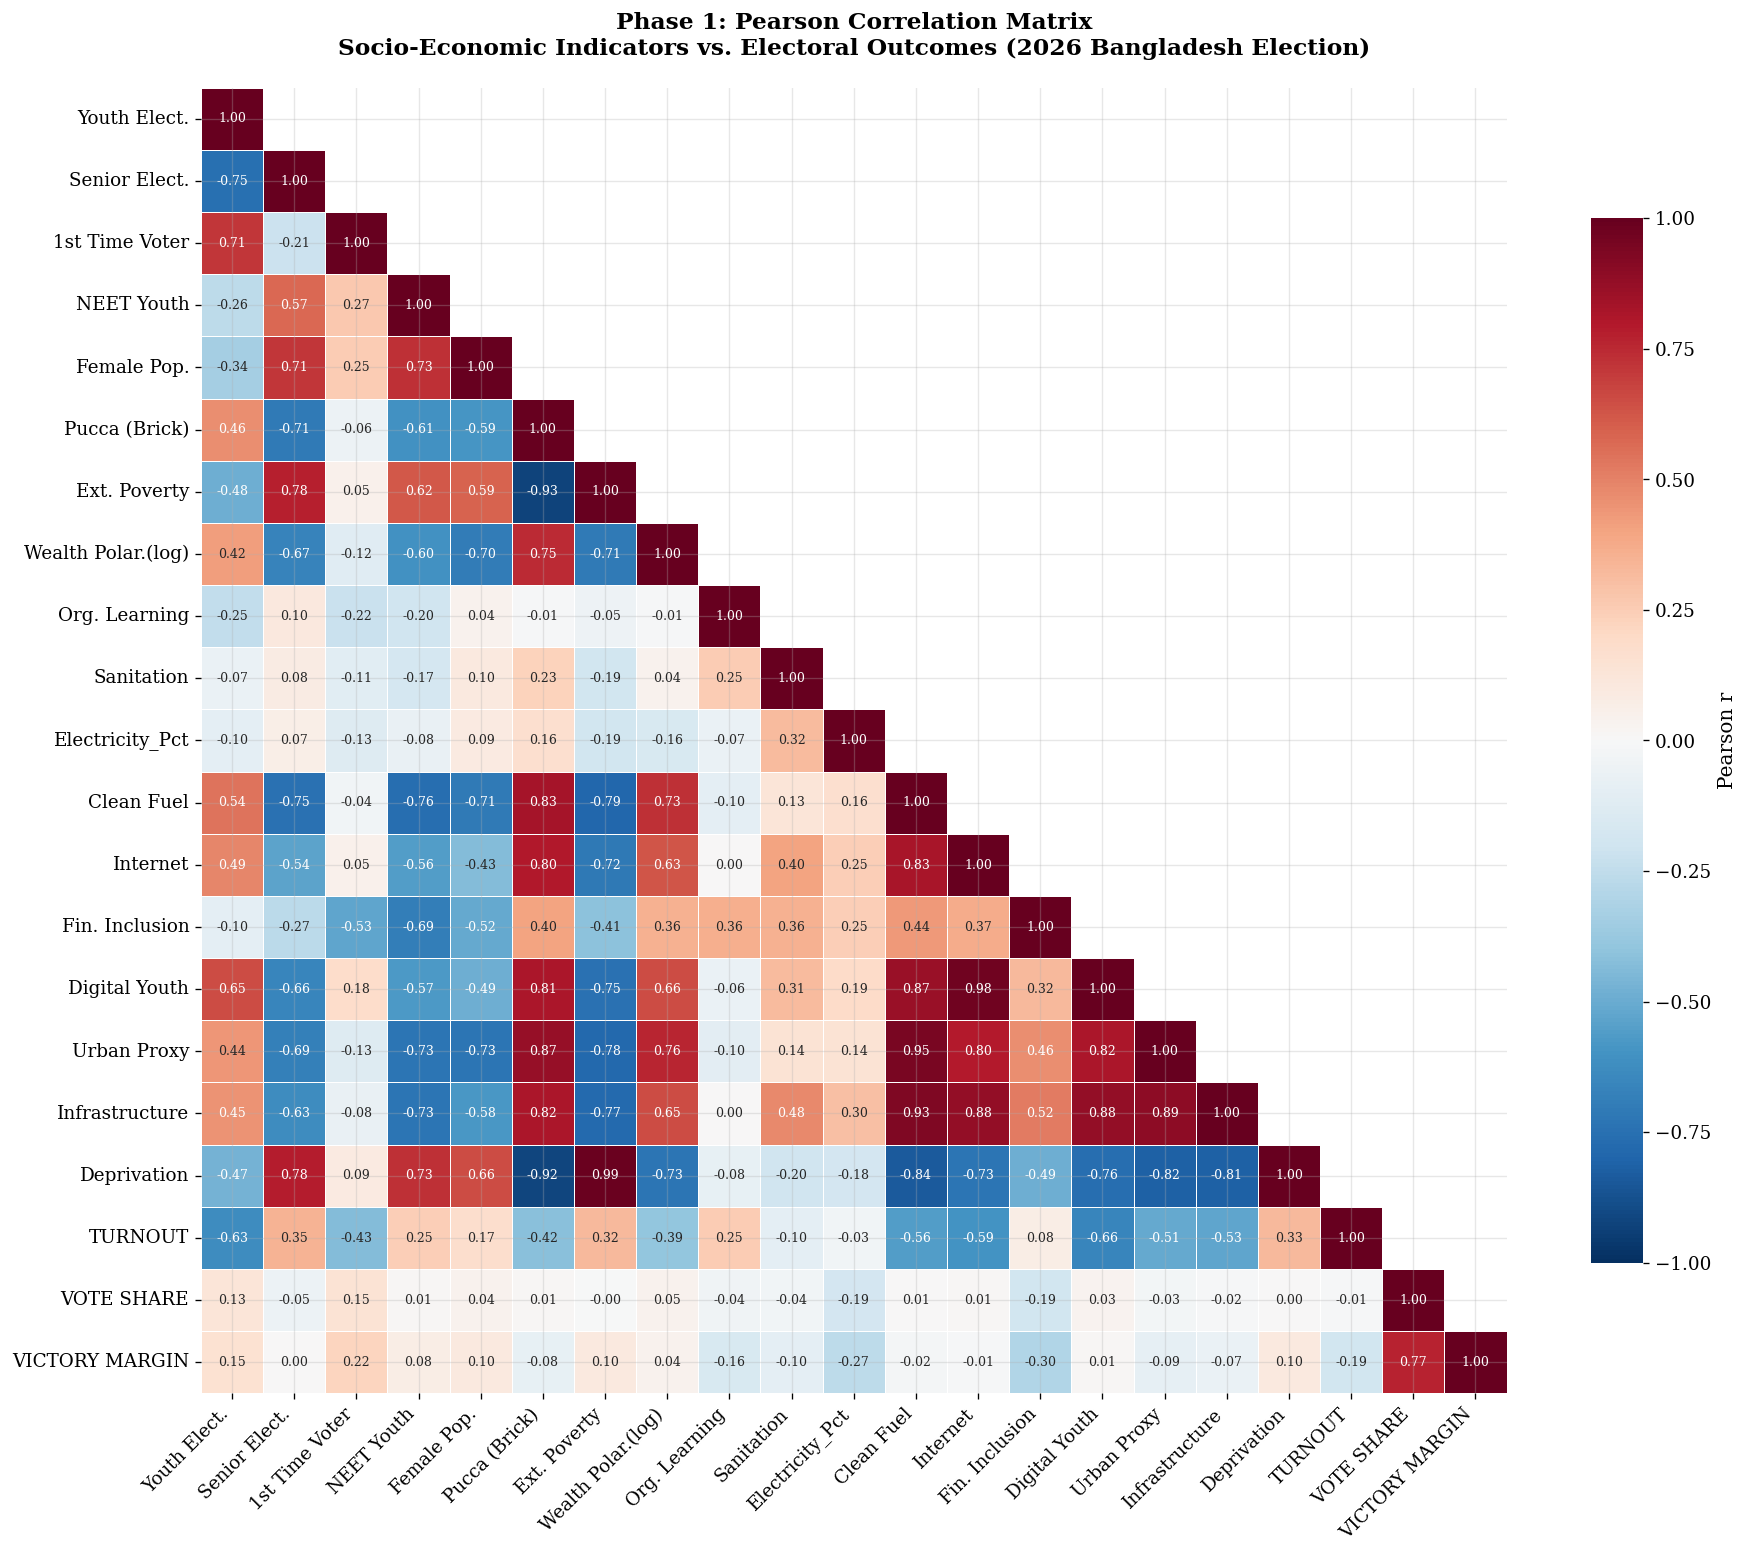

In [13]:
# Convert to Pandas for visualization
heatmap_pdf = grand_df.select(correlation_features).dropna().toPandas()
corr_matrix = heatmap_pdf.corr(method='pearson')

# Shortened labels for readability
label_map = {
    "Youth_Electorate_Pct": "Youth Elect.", "Senior_Electorate_Pct": "Senior Elect.",
    "First_Time_Voter_Pct": "1st Time Voter", "NEET_Youth_Pct": "NEET Youth",
    "Female_Pop_Pct": "Female Pop.", "Pucca_Pct": "Pucca (Brick)",
    "Extreme_Poverty_Pct": "Ext. Poverty", "WPI_Log": "Wealth Polar.(log)",
    "Organized_Learning_Pct": "Org. Learning", "Sanitation_Pct": "Sanitation",
    "Clean_Fuel_Pct": "Clean Fuel", "Internet_Pct": "Internet",
    "Financial_Inclusion_Pct": "Fin. Inclusion", "Digital_Youth_Index": "Digital Youth",
    "Urban_Proxy": "Urban Proxy", "Infrastructure_Composite": "Infrastructure",
    "Deprivation_Index": "Deprivation",
    "Voter_Turnout_Pct": "TURNOUT", "Winner_Vote_Share_Pct": "VOTE SHARE",
    "Victory_Margin_Pct": "VICTORY MARGIN"
}
corr_display = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

sns.heatmap(corr_display, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws={'size': 7.5}, ax=ax)

ax.set_title("Phase 1: Pearson Correlation Matrix\n"
    "Socio-Economic Indicators vs. Electoral Outcomes (2026 Bangladesh Election)",
    fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## Phase 4: K-Means Constituency Clustering

### Objective

Discover latent socio-economic archetypes among the 269 constituencies using unsupervised K-Means clustering, independent of any electoral outcome data. The resulting `Cluster_ID` will then be overlaid with actual election results to test whether socio-economically similar constituencies vote similarly. Crucially, `Cluster_ID` will also be injected as an engineered feature into the Phase 3 classification model, demonstrating a direct unsupervised-to-supervised learning pipeline.

### Spark MLlib Module
`pyspark.ml.clustering.KMeans` with `pyspark.ml.evaluation.ClusteringEvaluator` for Silhouette-based optimal K selection.

### Preprocessing
All 12 clustering features are standardized to zero mean and unit variance using `StandardScaler`, since K-Means uses Euclidean distance and is sensitive to feature scale. The raw `Wealth_Polarization_Index` is excluded in favor of `Pucca_Pct` and `Extreme_Poverty_Pct` separately to avoid distortion from extreme outliers (Gazipur-2: 1648.03).


In [14]:
print("=" * 80)
print("PHASE 4: K-MEANS CONSTITUENCY CLUSTERING")
print("=" * 80)

clustering_features = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "NEET_Youth_Pct",
    "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "Organized_Learning_Pct", "Sanitation_Pct", "Internet_Pct",
    "Clean_Fuel_Pct", "Financial_Inclusion_Pct", "First_Time_Voter_Pct",
]

cluster_input_df = grand_df.select(
    ["Constituency", "Coalition", "Winning_Party",
     "Voter_Turnout_Pct", "Winner_Vote_Share_Pct", "YES_Pct"]
    + clustering_features
).dropna(subset=clustering_features)

print(f"  Constituencies for clustering: {cluster_input_df.count()}")
print(f"  Features: {len(clustering_features)}")

# Vectorize and scale
assembler_cl = VectorAssembler(inputCols=clustering_features, outputCol="raw_features")
scaler_cl = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withMean=True, withStd=True)
cl_pipeline = Pipeline(stages=[assembler_cl, scaler_cl])
cl_model = cl_pipeline.fit(cluster_input_df)
scaled_df = cl_model.transform(cluster_input_df)

# --- Silhouette Analysis for Optimal K ---
print("\n=== SILHOUETTE ANALYSIS ===")
silhouette_scores = {}
for k in range(2, 11):
    km = KMeans(featuresCol="scaled_features", predictionCol=f"cl_k{k}", k=k, seed=488, maxIter=100)
    km_model = km.fit(scaled_df)
    preds = km_model.transform(scaled_df)
    sil = ClusteringEvaluator(featuresCol="scaled_features", predictionCol=f"cl_k{k}",
        metricName="silhouette", distanceMeasure="squaredEuclidean").evaluate(preds)
    silhouette_scores[k] = sil
    print(f"  K={k:2d}  |  Silhouette = {sil:.4f}  |  Cost = {km_model.summary.trainingCost:,.0f}")

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n  >>> OPTIMAL K = {optimal_k} (Silhouette = {silhouette_scores[optimal_k]:.4f})")


PHASE 4: K-MEANS CONSTITUENCY CLUSTERING
  Constituencies for clustering: 269
  Features: 12

=== SILHOUETTE ANALYSIS ===
  K= 2  |  Silhouette = 0.7078  |  Cost = 2,039
  K= 3  |  Silhouette = 0.4353  |  Cost = 1,608
  K= 4  |  Silhouette = 0.4136  |  Cost = 1,493
  K= 5  |  Silhouette = 0.3750  |  Cost = 1,331
  K= 6  |  Silhouette = 0.2859  |  Cost = 1,219
  K= 7  |  Silhouette = 0.2869  |  Cost = 1,139
  K= 8  |  Silhouette = 0.2760  |  Cost = 1,083
  K= 9  |  Silhouette = 0.2898  |  Cost = 1,012
  K=10  |  Silhouette = 0.2665  |  Cost = 984

  >>> OPTIMAL K = 2 (Silhouette = 0.7078)


### Silhouette Score Visualization

The Silhouette Score measures cluster separation quality on a scale of -1 to +1. Values above 0.3 indicate meaningful cluster structure. We select the K that maximizes this metric.


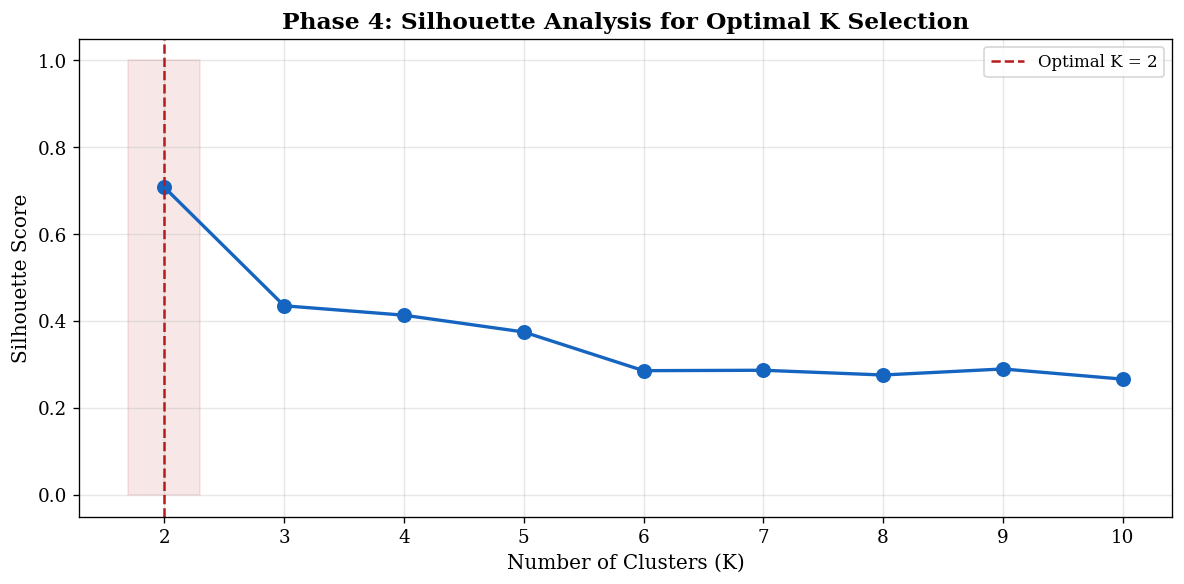

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ks = list(silhouette_scores.keys())
sils = list(silhouette_scores.values())

ax.plot(ks, sils, 'o-', color=PALETTE_ACCENT, linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color=PALETTE_JAMAAT, linestyle='--', linewidth=1.5,
    label=f'Optimal K = {optimal_k}')
ax.fill_between([optimal_k - 0.3, optimal_k + 0.3], 0, 1, alpha=0.1, color=PALETTE_JAMAAT)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Phase 4: Silhouette Analysis for Optimal K Selection")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


### Final K-Means Model and Cluster-Coalition Cross-Tabulation

With the optimal K determined, we train the final K-Means model and examine how election coalitions distribute across the discovered socio-economic clusters. If certain clusters show dominant single-coalition voting, this provides evidence that socio-economic conditions structurally determine political allegiance.


In [16]:
# Train final model
final_km = KMeans(featuresCol="scaled_features", predictionCol="Cluster_ID",
    k=optimal_k, seed=488, maxIter=200)
final_km_model = final_km.fit(scaled_df)
clustered_df = final_km_model.transform(scaled_df)

print("=== CLUSTER SIZES ===")
clustered_df.groupBy("Cluster_ID").count().orderBy("Cluster_ID").show()

# Cluster profiles
print("=== CLUSTER SOCIO-ECONOMIC PROFILES ===")
profile_cols = clustering_features + ["Voter_Turnout_Pct"]
agg_exprs = [F.round(F.avg(F.col(c)), 2).alias(c) for c in profile_cols]
clustered_df.groupBy("Cluster_ID").agg(*agg_exprs).orderBy("Cluster_ID").show(truncate=False)

# Cluster x Coalition Cross-Tabulation
print("=== CLUSTER x COALITION CROSS-TABULATION ===")
cross_tab = clustered_df.groupBy("Cluster_ID", "Coalition").count() \
    .orderBy("Cluster_ID", F.col("count").desc())

total_per = clustered_df.groupBy("Cluster_ID").agg(F.count("*").alias("total"))
dominance = cross_tab.join(total_per, on="Cluster_ID") \
    .withColumn("Pct", F.round((F.col("count") / F.col("total")) * 100, 1)) \
    .orderBy("Cluster_ID", F.col("Pct").desc())
dominance.show(50, truncate=False)

# Gopalganj anomaly check
print("=== GOPALGANJ ANOMALY CHECK ===")
clustered_df.filter(F.col("Constituency").startswith("Gopalganj")).select(
    "Constituency", "Cluster_ID", "Coalition", "Voter_Turnout_Pct", "YES_Pct"
).show(truncate=False)

# Append Cluster_ID to grand dataframe
cluster_labels = clustered_df.select("Constituency", "Cluster_ID")
grand_df_enriched = grand_df.join(cluster_labels, on="Constituency", how="left")
grand_df_enriched = grand_df_enriched.fillna({"Cluster_ID": -1})
grand_df_enriched.cache()
print(f"\nEnriched DataFrame: {grand_df_enriched.count()} rows x {len(grand_df_enriched.columns)} cols")
print("Cluster_ID appended successfully.")


=== CLUSTER SIZES ===
+----------+-----+
|Cluster_ID|count|
+----------+-----+
|         0|  235|
|         1|   34|
+----------+-----+

=== CLUSTER SOCIO-ECONOMIC PROFILES ===
+----------+--------------------+---------------------+--------------+--------------+---------+-------------------+----------------------+--------------+------------+--------------+-----------------------+--------------------+-----------------+
|Cluster_ID|Youth_Electorate_Pct|Senior_Electorate_Pct|NEET_Youth_Pct|Female_Pop_Pct|Pucca_Pct|Extreme_Poverty_Pct|Organized_Learning_Pct|Sanitation_Pct|Internet_Pct|Clean_Fuel_Pct|Financial_Inclusion_Pct|First_Time_Voter_Pct|Voter_Turnout_Pct|
+----------+--------------------+---------------------+--------------+--------------+---------+-------------------+----------------------+--------------+------------+--------------+-----------------------+--------------------+-----------------+
|0         |37.44               |14.07                |35.89         |51.07         |16.

## Phase 2: Regression Analysis

### Objective

Build two regression models to predict continuous electoral outcomes from socio-economic indicators:

- **Model A (Voter Turnout)**: Uses Linear Regression with ElasticNet regularization to predict `Voter_Turnout_Pct`. ElasticNet combines L1 (Lasso) and L2 (Ridge) penalties, which is theoretically appropriate here because (1) L1 performs automatic feature selection among correlated housing variables, and (2) L2 handles residual multicollinearity between `Pucca_Pct` and `Extreme_Poverty_Pct`.

- **Model B (Winner Vote Share)**: Uses Random Forest Regression to predict `Winner_Vote_Share_Pct`. The non-parametric nature of Random Forest is well-suited for capturing non-linear relationships between socio-economic conditions and mandate strength.

### Evaluation Metrics

| Metric | Definition | Acceptability Threshold |
|---|---|---|
| R-squared (R2) | Proportion of variance explained | > 0.40 for political data |
| RMSE | Root Mean Squared Error in percentage points | < 8% for turnout |
| MAE | Mean Absolute Error (robust to outliers) | Contextual |


In [17]:
print("=" * 80)
print("PHASE 2: REGRESSION ANALYSIS")
print("=" * 80)

REGRESSION_FEATURES = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "WPI_Log", "Organized_Learning_Pct", "Sanitation_Pct", "Clean_Fuel_Pct",
    "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite", "Deprivation_Index",
]

reg_targets = ["Voter_Turnout_Pct", "Winner_Vote_Share_Pct"]
reg_df = grand_df_enriched.select(["Constituency"] + REGRESSION_FEATURES + reg_targets) \
    .dropna(subset=REGRESSION_FEATURES + reg_targets)
for c in REGRESSION_FEATURES + reg_targets:
    reg_df = reg_df.withColumn(c, F.col(c).cast(DoubleType()))

train_reg, test_reg = reg_df.randomSplit([0.8, 0.2], seed=488)
print(f"  Training: {train_reg.count()} rows | Test: {test_reg.count()} rows")

# === MODEL A: Linear Regression for Voter Turnout ===
print("\n--- MODEL A: LINEAR REGRESSION (Voter Turnout) ---")
pipe_a = Pipeline(stages=[
    VectorAssembler(inputCols=REGRESSION_FEATURES, outputCol="raw_feat_a", handleInvalid="skip"),
    StandardScaler(inputCol="raw_feat_a", outputCol="features_a", withMean=True, withStd=True),
    LinearRegression(featuresCol="features_a", labelCol="Voter_Turnout_Pct",
        predictionCol="pred_turnout", maxIter=100, regParam=0.1, elasticNetParam=0.5,
        standardization=False)
])
model_a = pipe_a.fit(train_reg)
pred_a = model_a.transform(test_reg)

r2_a = RegressionEvaluator(labelCol="Voter_Turnout_Pct", predictionCol="pred_turnout", metricName="r2").evaluate(pred_a)
rmse_a = RegressionEvaluator(labelCol="Voter_Turnout_Pct", predictionCol="pred_turnout", metricName="rmse").evaluate(pred_a)
mae_a = RegressionEvaluator(labelCol="Voter_Turnout_Pct", predictionCol="pred_turnout", metricName="mae").evaluate(pred_a)

print(f"  R2 = {r2_a:.4f} | RMSE = {rmse_a:.2f}% | MAE = {mae_a:.2f}%")

# Extract coefficients
lr_model = model_a.stages[-1]
coefficients_a = lr_model.coefficients.toArray()
coeff_data = [{"Feature": f, "Coefficient": c, "Abs": abs(c)}
    for f, c in zip(REGRESSION_FEATURES, coefficients_a)]
coeff_pdf = pd.DataFrame(coeff_data).sort_values("Abs", ascending=False)
print("\n  Top 5 Turnout Predictors:")
for _, row in coeff_pdf.head(5).iterrows():
    d = "INCREASES" if row["Coefficient"] > 0 else "DECREASES"
    print(f"    {row['Feature']:<30s}  coeff={row['Coefficient']:+.4f}  ({d} turnout)")

turnout_pred_pdf = pred_a.select("Voter_Turnout_Pct", "pred_turnout").toPandas()

# === MODEL B: Random Forest Regression for Vote Share ===
print("\n--- MODEL B: RANDOM FOREST REGRESSION (Vote Share) ---")
FEATURES_B = REGRESSION_FEATURES + ["Voter_Turnout_Pct"]
pipe_b = Pipeline(stages=[
    VectorAssembler(inputCols=FEATURES_B, outputCol="features_b", handleInvalid="skip"),
    RandomForestRegressor(featuresCol="features_b", labelCol="Winner_Vote_Share_Pct",
        predictionCol="pred_voteshare", numTrees=200, maxDepth=8,
        featureSubsetStrategy="sqrt", minInstancesPerNode=3, seed=488)
])
model_b = pipe_b.fit(train_reg)
pred_b = model_b.transform(test_reg)

r2_b = RegressionEvaluator(labelCol="Winner_Vote_Share_Pct", predictionCol="pred_voteshare", metricName="r2").evaluate(pred_b)
rmse_b = RegressionEvaluator(labelCol="Winner_Vote_Share_Pct", predictionCol="pred_voteshare", metricName="rmse").evaluate(pred_b)
mae_b = RegressionEvaluator(labelCol="Winner_Vote_Share_Pct", predictionCol="pred_voteshare", metricName="mae").evaluate(pred_b)

print(f"  R2 = {r2_b:.4f} | RMSE = {rmse_b:.2f}% | MAE = {mae_b:.2f}%")

# Feature importances (Model B)
fi_b = model_b.stages[-1].featureImportances.toArray()
fi_pdf_b = pd.DataFrame([{"Feature": f, "Importance": v} for f,v in zip(FEATURES_B, fi_b)]) \
    .sort_values("Importance", ascending=False)
print("\n  Top 5 Vote Share Predictors:")
for _, row in fi_pdf_b.head(5).iterrows():
    print(f"    {row['Feature']:<30s}  importance={row['Importance']:.4f}")

voteshare_pred_pdf = pred_b.select("Winner_Vote_Share_Pct", "pred_voteshare").toPandas()

print("\nPhase 2 regression analysis complete.")


PHASE 2: REGRESSION ANALYSIS
  Training: 216 rows | Test: 52 rows

--- MODEL A: LINEAR REGRESSION (Voter Turnout) ---
  R2 = 0.6302 | RMSE = 5.23% | MAE = 4.44%

  Top 5 Turnout Predictors:
    Youth_Electorate_Pct            coeff=-5.7970  (DECREASES turnout)
    Senior_Electorate_Pct           coeff=-5.7766  (DECREASES turnout)
    Clean_Fuel_Pct                  coeff=-3.1092  (DECREASES turnout)
    Urban_Proxy                     coeff=-2.0894  (DECREASES turnout)
    Digital_Youth_Index             coeff=-1.9939  (DECREASES turnout)

--- MODEL B: RANDOM FOREST REGRESSION (Vote Share) ---
  R2 = -0.0051 | RMSE = 9.54% | MAE = 6.94%

  Top 5 Vote Share Predictors:
    First_Time_Voter_Pct            importance=0.0808
    Sanitation_Pct                  importance=0.0769
    Financial_Inclusion_Pct         importance=0.0760
    NEET_Youth_Pct                  importance=0.0649
    Organized_Learning_Pct          importance=0.0635

Phase 2 regression analysis complete.


### Phase 2 Visualizations: Actual vs. Predicted Plots

The scatter plots below compare actual electoral outcomes against model predictions. Points clustering tightly along the y=x diagonal indicate high predictive accuracy. The residual histogram (Model A) reveals whether prediction errors are normally distributed, a key assumption of linear regression.


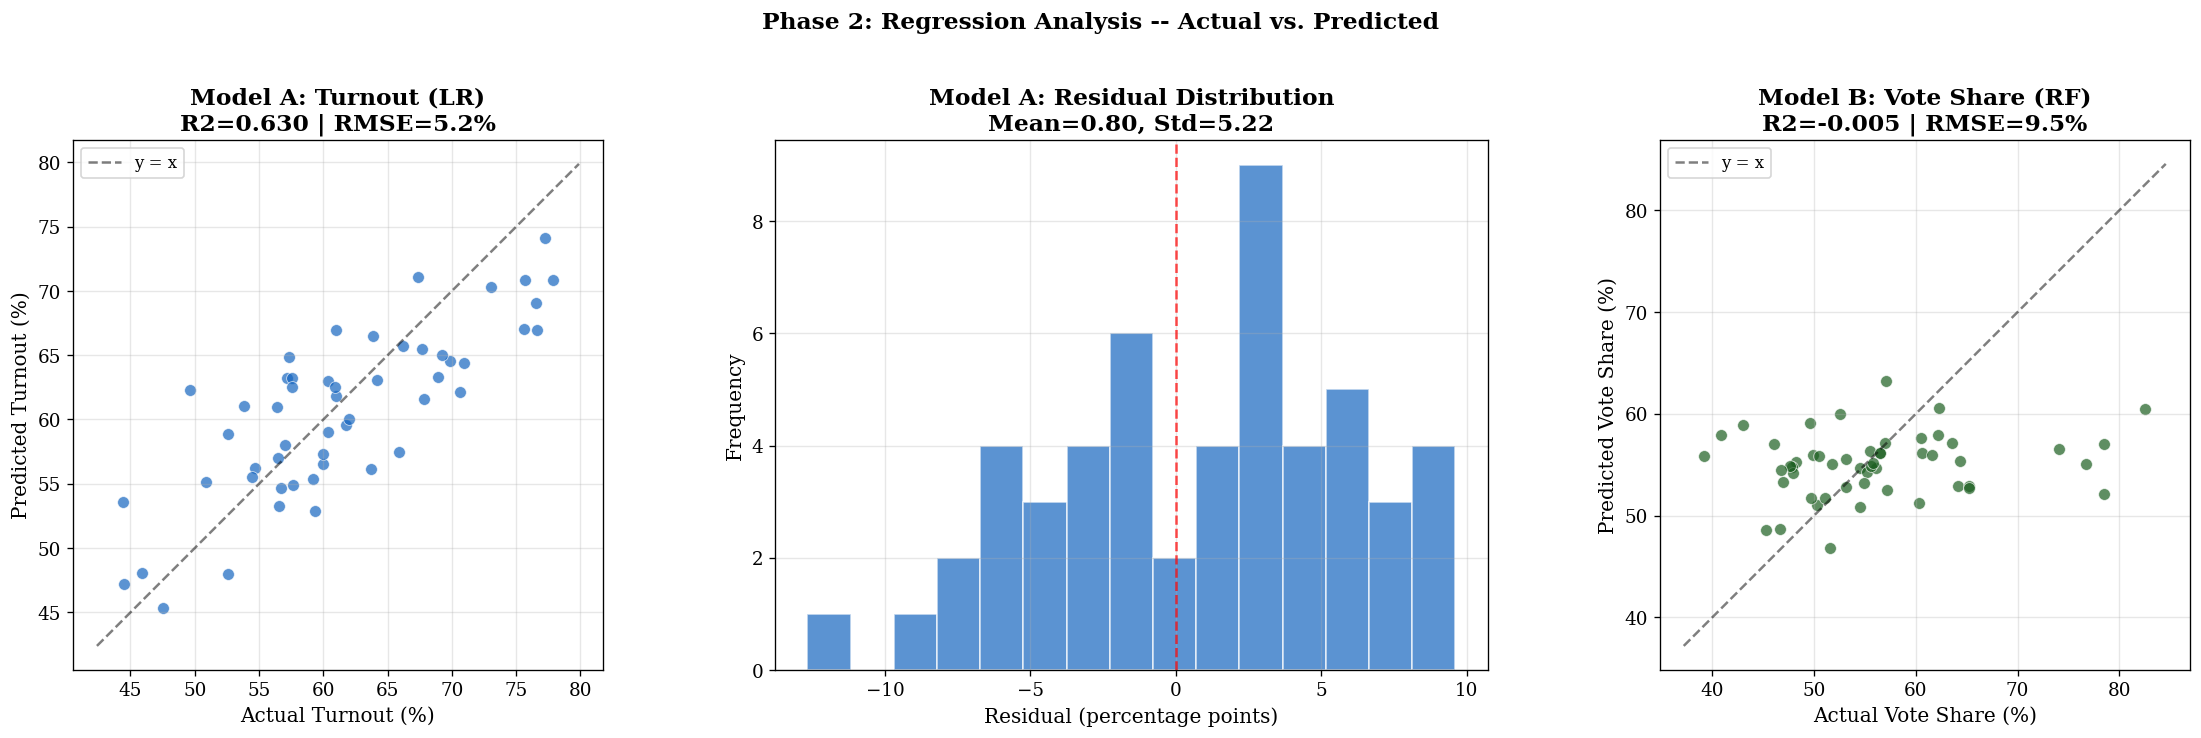

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Model A: Actual vs Predicted Turnout ---
ax1 = axes[0]
ax1.scatter(turnout_pred_pdf["Voter_Turnout_Pct"], turnout_pred_pdf["pred_turnout"],
    alpha=0.7, s=50, c=PALETTE_ACCENT, edgecolors='white', linewidth=0.5)
lims_a = [min(turnout_pred_pdf.min()) - 2, max(turnout_pred_pdf.max()) + 2]
ax1.plot(lims_a, lims_a, 'k--', alpha=0.5, linewidth=1.5, label='y = x')
ax1.set_xlabel("Actual Turnout (%)")
ax1.set_ylabel("Predicted Turnout (%)")
ax1.set_title(f"Model A: Turnout (LR)\nR2={r2_a:.3f} | RMSE={rmse_a:.1f}%")
ax1.legend()
ax1.set_aspect('equal')

# --- Model A: Residuals ---
ax2 = axes[1]
resid = turnout_pred_pdf["Voter_Turnout_Pct"] - turnout_pred_pdf["pred_turnout"]
ax2.hist(resid, bins=15, color=PALETTE_ACCENT, alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel("Residual (percentage points)")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Model A: Residual Distribution\nMean={resid.mean():.2f}, Std={resid.std():.2f}")

# --- Model B: Actual vs Predicted Vote Share ---
ax3 = axes[2]
ax3.scatter(voteshare_pred_pdf["Winner_Vote_Share_Pct"], voteshare_pred_pdf["pred_voteshare"],
    alpha=0.7, s=50, c=PALETTE_BNP, edgecolors='white', linewidth=0.5)
lims_b = [min(voteshare_pred_pdf.min()) - 2, max(voteshare_pred_pdf.max()) + 2]
ax3.plot(lims_b, lims_b, 'k--', alpha=0.5, linewidth=1.5, label='y = x')
ax3.set_xlabel("Actual Vote Share (%)")
ax3.set_ylabel("Predicted Vote Share (%)")
ax3.set_title(f"Model B: Vote Share (RF)\nR2={r2_b:.3f} | RMSE={rmse_b:.1f}%")
ax3.legend()
ax3.set_aspect('equal')

plt.suptitle("Phase 2: Regression Analysis -- Actual vs. Predicted", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("phase2_regression_plots.png", dpi=150, bbox_inches='tight')
plt.show()


## Phase 3: Classification (Capstone Analysis)

### Objective

Predict which political coalition -- **BNP Coalition** or **Jamaat/Reform Coalition** -- won each constituency using only pre-election socio-economic census data. This is the most politically significant analysis in the project: if a Random Forest classifier can predict the winning coalition from demographics alone, it implies that election outcomes in Bangladesh are structurally determined by socio-economic conditions rather than campaign dynamics.

### Methodological Decisions

1. **Binary Classification**: We filter out the minor "INDEPENDENT_OTHER" class to focus on the dominant bipolar contest. This maximizes model precision and aligns with the political reality of the 2026 election.

2. **Class Weighting**: BNP won approximately 209 seats versus Jamaat's 77. Without correction, the classifier could achieve ~73% accuracy by trivially predicting BNP for every constituency. We apply **inverse-frequency weighting** (`weight = N_total / (2 * N_class)`) to force the algorithm to learn genuine discriminative patterns rather than exploiting class imbalance.

3. **Cluster_ID Integration**: The `Cluster_ID` engineered by the K-Means model in Phase 4 is included as a classification feature. This demonstrates a direct unsupervised-to-supervised learning pipeline linkage, where constituency archetype information feeds into coalition prediction.

4. **Stratified Split**: The 80/20 train-test split is performed per class and unioned, preserving class proportions in both partitions.

### Spark MLlib Modules
- `pyspark.ml.classification.RandomForestClassifier`
- `pyspark.ml.feature.StringIndexer` (target encoding)
- `pyspark.ml.evaluation.MulticlassClassificationEvaluator`


In [19]:
print("=" * 80)
print("PHASE 3: RANDOM FOREST CLASSIFICATION -- COALITION PREDICTION")
print("=" * 80)

# --- Filter to binary target ---
clf_df = grand_df_enriched.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"]))
print(f"  Binary dataset: {clf_df.count()} constituencies")
print(f"  Excluded: {grand_df_enriched.count() - clf_df.count()} INDEPENDENT_OTHER seats")

clf_df.groupBy("Coalition").count().orderBy(F.col("count").desc()).show()

CLASSIFICATION_FEATURES = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "First_Time_Voter_Pct",
    "NEET_Youth_Pct", "Female_Pop_Pct", "Pucca_Pct", "Extreme_Poverty_Pct",
    "WPI_Log", "Organized_Learning_Pct", "Sanitation_Pct", "Clean_Fuel_Pct",
    "Internet_Pct", "Financial_Inclusion_Pct",
    "Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite",
    "Deprivation_Index", "Cluster_ID",
]

clf_df = clf_df.withColumn("Cluster_ID", F.col("Cluster_ID").cast(DoubleType()))
clf_df = clf_df.select(["Constituency", "Coalition", "Winning_Party"] + CLASSIFICATION_FEATURES) \
    .dropna(subset=CLASSIFICATION_FEATURES + ["Coalition"])

# --- StringIndexer for target ---
label_indexer = StringIndexer(inputCol="Coalition", outputCol="label", handleInvalid="skip")
label_model = label_indexer.fit(clf_df)
clf_df = label_model.transform(clf_df)
label_mapping = list(label_model.labels)
print("\n  Label Encoding:")
for idx, name in enumerate(label_mapping):
    print(f"    {idx} -> {name} ({clf_df.filter(F.col('label')==idx).count()} seats)")

# --- Class weighting ---
total = clf_df.count()
class_counts = clf_df.groupBy("label").count().collect()
weight_map = {row["label"]: total / (2.0 * row["count"]) for row in class_counts}
weight_expr = F.lit(0.0)
for lv, wv in weight_map.items():
    weight_expr = F.when(F.col("label") == lv, wv).otherwise(weight_expr)
clf_df = clf_df.withColumn("classWeight", weight_expr)

print("\n  Class Weights:")
for lv, wv in weight_map.items():
    print(f"    {label_mapping[int(lv)]}: {wv:.4f}")

# --- Stratified split ---
train_0, test_0 = clf_df.filter(F.col("label")==0).randomSplit([0.8,0.2], seed=488)
train_1, test_1 = clf_df.filter(F.col("label")==1).randomSplit([0.8,0.2], seed=488)
train_clf = train_0.union(train_1)
test_clf = test_0.union(test_1)
print(f"\n  Stratified Split: Train={train_clf.count()} | Test={test_clf.count()}")

# --- Build and train pipeline ---
clf_pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=CLASSIFICATION_FEATURES, outputCol="features", handleInvalid="skip"),
    RandomForestClassifier(featuresCol="features", labelCol="label", predictionCol="prediction",
        probabilityCol="probability", rawPredictionCol="rawPrediction",
        weightCol="classWeight", numTrees=200, maxDepth=8,
        featureSubsetStrategy="sqrt", minInstancesPerNode=3, seed=488)
])

print("  Training Random Forest Classifier (200 trees)...")
clf_model = clf_pipeline.fit(train_clf)
predictions = clf_model.transform(test_clf)
print("  Training complete.")

# --- Evaluation ---
accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
f1_score = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(predictions)
precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision").evaluate(predictions)
recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall").evaluate(predictions)
auc_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(predictions)

majority_baseline = max(train_0.count()+test_0.count(), train_1.count()+test_1.count()) / total

print(f"\n  {'='*55}")
print(f"  {'CLASSIFICATION RESULTS':^55}")
print(f"  {'='*55}")
print(f"  {'Accuracy':<35s} {accuracy:.4f}")
print(f"  {'Weighted Precision':<35s} {precision:.4f}")
print(f"  {'Weighted Recall':<35s} {recall:.4f}")
print(f"  {'Weighted F1-Score':<35s} {f1_score:.4f}")
print(f"  {'AUC-ROC':<35s} {auc_roc:.4f}")
print(f"  {'Majority-Class Baseline':<35s} {majority_baseline:.4f}")
print(f"  {'Improvement over Baseline':<35s} {accuracy - majority_baseline:+.4f}")

# --- Per-class metrics ---
for lv in [0, 1]:
    name = label_mapping[int(lv)]
    tp = predictions.filter((F.col("label")==lv)&(F.col("prediction")==lv)).count()
    fp = predictions.filter((F.col("label")!=lv)&(F.col("prediction")==lv)).count()
    fn = predictions.filter((F.col("label")==lv)&(F.col("prediction")!=lv)).count()
    p = tp/(tp+fp) if tp+fp>0 else 0
    r = tp/(tp+fn) if tp+fn>0 else 0
    f = 2*p*r/(p+r) if p+r>0 else 0
    print(f"\n  [{name}]  TP={tp} FP={fp} FN={fn} | P={p:.4f} R={r:.4f} F1={f:.4f}")


PHASE 3: RANDOM FOREST CLASSIFICATION -- COALITION PREDICTION
  Binary dataset: 263 constituencies
  Excluded: 6 INDEPENDENT_OTHER seats
+-------------+-----+
|    Coalition|count|
+-------------+-----+
|BNP_COALITION|  191|
|JAMAAT_REFORM|   72|
+-------------+-----+


  Label Encoding:
    0 -> BNP_COALITION (191 seats)
    1 -> JAMAAT_REFORM (72 seats)

  Class Weights:
    JAMAAT_REFORM: 1.8264
    BNP_COALITION: 0.6885

  Stratified Split: Train=207 | Test=56
  Training Random Forest Classifier (200 trees)...
  Training complete.

                  CLASSIFICATION RESULTS                 
  Accuracy                            0.7679
  Weighted Precision                  0.7589
  Weighted Recall                     0.7679
  Weighted F1-Score                   0.7609
  AUC-ROC                             0.7738
  Majority-Class Baseline             0.7262
  Improvement over Baseline           +0.0416

  [BNP_COALITION]  TP=34 FP=8 FN=5 | P=0.8095 R=0.8718 F1=0.8395

  [JAMAAT_REFORM]

### Phase 3: Feature Importances -- The Ultimate Deciders

The Random Forest `featureImportances` vector quantifies each feature's contribution to classification accuracy via mean decrease in Gini impurity. This directly answers the project's central thesis: **which socio-economic factor was the primary determinant of coalition victory in the 2026 Bangladesh election?**


In [20]:
rf_model = clf_model.stages[-1]
importances = rf_model.featureImportances.toArray()

fi_data = [{"Feature": f, "Importance": v} for f, v in zip(CLASSIFICATION_FEATURES, importances)]
fi_pdf = pd.DataFrame(fi_data).sort_values("Importance", ascending=False)

print("=== FEATURE IMPORTANCE RANKING ===")
cumulative = 0.0
for rank, (_, row) in enumerate(fi_pdf.iterrows(), 1):
    cumulative += row["Importance"]
    print(f"  {rank:2d}. {row['Feature']:<30s}  {row['Importance']:.4f}  (cum: {cumulative:.4f})")

cluster_imp = fi_pdf[fi_pdf["Feature"]=="Cluster_ID"]["Importance"].values[0]
cluster_rank = list(fi_pdf["Feature"]).index("Cluster_ID") + 1
print(f"\n  Cluster_ID Importance: {cluster_imp:.4f} (Rank {cluster_rank}/{len(CLASSIFICATION_FEATURES)})")


=== FEATURE IMPORTANCE RANKING ===
   1. Youth_Electorate_Pct            0.1259  (cum: 0.1259)
   2. First_Time_Voter_Pct            0.1201  (cum: 0.2461)
   3. NEET_Youth_Pct                  0.0696  (cum: 0.3157)
   4. Digital_Youth_Index             0.0626  (cum: 0.3782)
   5. Infrastructure_Composite        0.0623  (cum: 0.4405)
   6. Internet_Pct                    0.0563  (cum: 0.4968)
   7. Organized_Learning_Pct          0.0549  (cum: 0.5518)
   8. Pucca_Pct                       0.0508  (cum: 0.6026)
   9. Clean_Fuel_Pct                  0.0498  (cum: 0.6524)
  10. Extreme_Poverty_Pct             0.0488  (cum: 0.7012)
  11. WPI_Log                         0.0467  (cum: 0.7479)
  12. Sanitation_Pct                  0.0461  (cum: 0.7940)
  13. Deprivation_Index               0.0460  (cum: 0.8400)
  14. Financial_Inclusion_Pct         0.0428  (cum: 0.8827)
  15. Senior_Electorate_Pct           0.0413  (cum: 0.9240)
  16. Female_Pop_Pct                  0.0399  (cum: 0.9640)
  17.

### Visualization: Feature Importance Bar Chart

The color coding distinguishes three feature categories:
- **Green**: Raw census features from the BBS 2022 data
- **Blue**: Engineered composite features created during the data engineering phase
- **Amber**: `Cluster_ID` from the Phase 4 K-Means model, demonstrating the unsupervised-to-supervised pipeline linkage


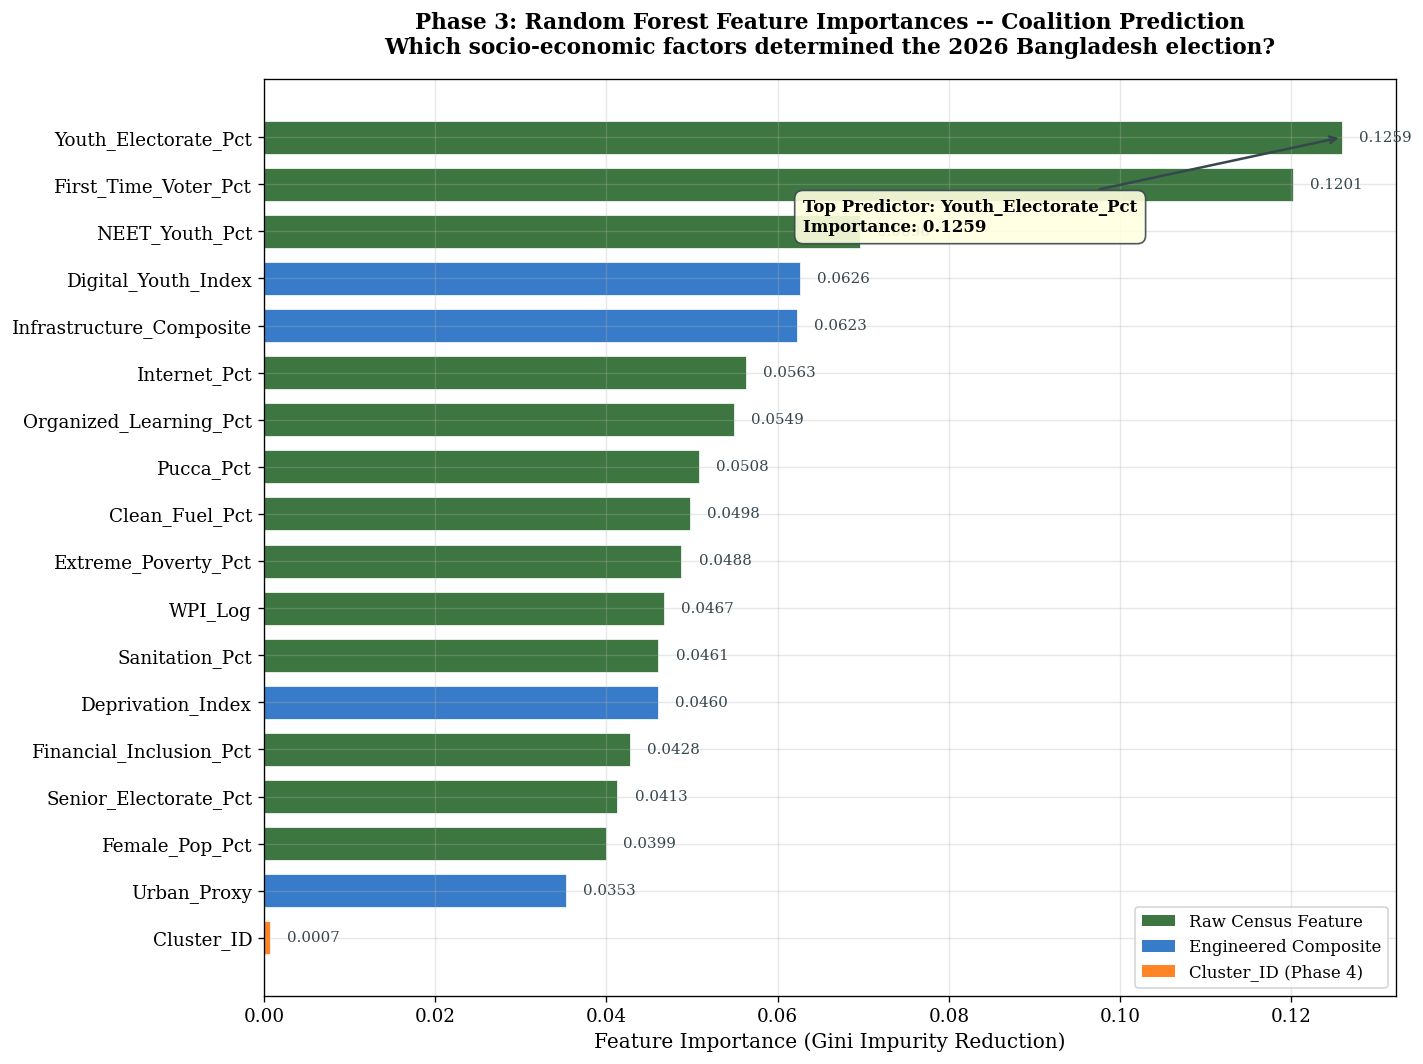

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))
fi_sorted = fi_pdf.sort_values("Importance", ascending=True)

colors = []
for feat in fi_sorted["Feature"]:
    if feat == "Cluster_ID":
        colors.append('#FF6F00')
    elif feat in ["Digital_Youth_Index", "Urban_Proxy", "Infrastructure_Composite", "Deprivation_Index"]:
        colors.append('#1565C0')
    else:
        colors.append(PALETTE_BNP)

bars = ax.barh(fi_sorted["Feature"], fi_sorted["Importance"],
    color=colors, alpha=0.85, edgecolor='white', linewidth=0.5, height=0.7)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2, f'{w:.4f}',
        va='center', fontsize=9, color=PALETTE_NEUTRAL)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE_BNP, alpha=0.85, label='Raw Census Feature'),
    Patch(facecolor='#1565C0', alpha=0.85, label='Engineered Composite'),
    Patch(facecolor='#FF6F00', alpha=0.85, label='Cluster_ID (Phase 4)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel("Feature Importance (Gini Impurity Reduction)")
ax.set_title("Phase 3: Random Forest Feature Importances -- Coalition Prediction\n"
    "Which socio-economic factors determined the 2026 Bangladesh election?",
    fontsize=13, fontweight='bold', pad=15)

top = fi_sorted.iloc[-1]
ax.annotate(f'Top Predictor: {top["Feature"]}\nImportance: {top["Importance"]:.4f}',
    xy=(top["Importance"], len(fi_sorted)-1),
    xytext=(top["Importance"]*0.5, len(fi_sorted)-3),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PALETTE_NEUTRAL, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor=PALETTE_NEUTRAL, alpha=0.9))

plt.tight_layout()
plt.savefig("phase3_feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()


### Visualization: Confusion Matrix


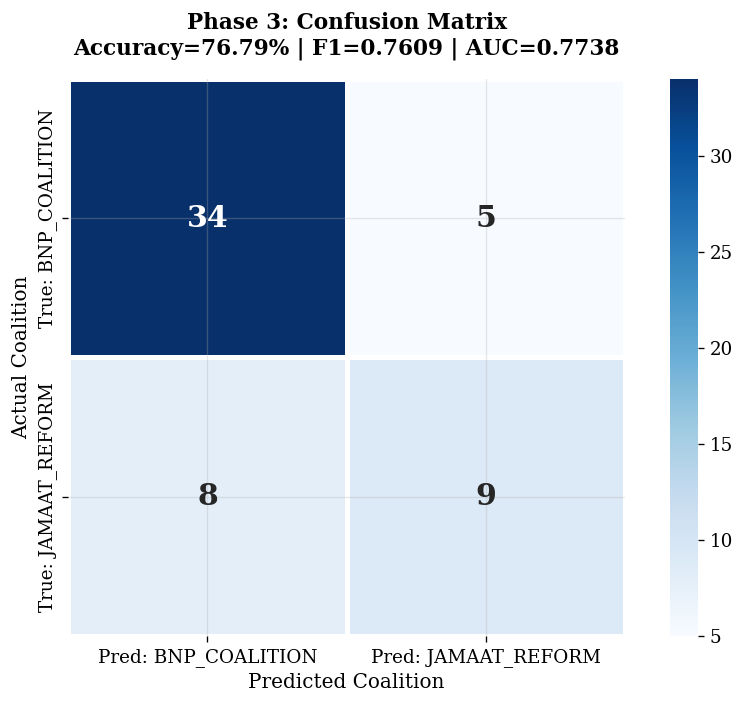

In [22]:
from sklearn.metrics import confusion_matrix as sk_cm

cm_pdf = predictions.select("label", "prediction").toPandas()
cm = sk_cm(cm_pdf["label"], cm_pdf["prediction"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f"Pred: {l}" for l in label_mapping],
    yticklabels=[f"True: {l}" for l in label_mapping],
    linewidths=2, linecolor='white', square=True,
    annot_kws={'size': 18, 'fontweight': 'bold'}, ax=ax)

ax.set_xlabel("Predicted Coalition", fontsize=12)
ax.set_ylabel("Actual Coalition", fontsize=12)
ax.set_title(f"Phase 3: Confusion Matrix\n"
    f"Accuracy={accuracy:.2%} | F1={f1_score:.4f} | AUC={auc_roc:.4f}",
    fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("phase3_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


### Phase 3 Ablation Study: Quantifying the Value of K-Means Clustering

To rigorously test whether the unsupervised clustering from Phase 4 provides genuine predictive value, we run an **ablation study**: the identical Random Forest classifier is re-trained on the same data with the `Cluster_ID` feature removed. The performance delta between the two models directly quantifies the contribution of constituency archetype information to coalition prediction.

This is a standard technique in machine learning research to validate feature utility and is particularly important here because it proves the inter-phase dependency chain: Phase 4 (unsupervised) feeds into Phase 3 (supervised).


In [23]:
print("=" * 80)
print("ABLATION STUDY: WITH vs WITHOUT CLUSTER_ID")
print("=" * 80)

FEATURES_NC = [f for f in CLASSIFICATION_FEATURES if f != "Cluster_ID"]

pipe_nc = Pipeline(stages=[
    VectorAssembler(inputCols=FEATURES_NC, outputCol="features_nc", handleInvalid="skip"),
    RandomForestClassifier(featuresCol="features_nc", labelCol="label",
        predictionCol="pred_nc", probabilityCol="prob_nc", rawPredictionCol="raw_nc",
        weightCol="classWeight", numTrees=200, maxDepth=8,
        featureSubsetStrategy="sqrt", minInstancesPerNode=3, seed=488)
])

model_nc = pipe_nc.fit(train_clf)
pred_nc = model_nc.transform(test_clf)

acc_nc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="pred_nc", metricName="accuracy").evaluate(pred_nc)
f1_nc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="pred_nc", metricName="f1").evaluate(pred_nc)
auc_nc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="raw_nc", metricName="areaUnderROC").evaluate(pred_nc)

print(f"\n  {'Metric':<25s} {'With Cluster':<15s} {'Without':<15s} {'Delta':>10s}")
print(f"  {'-'*65}")
print(f"  {'Accuracy':<25s} {accuracy:<15.4f} {acc_nc:<15.4f} {accuracy-acc_nc:>+10.4f}")
print(f"  {'F1-Score':<25s} {f1_score:<15.4f} {f1_nc:<15.4f} {f1_score-f1_nc:>+10.4f}")
print(f"  {'AUC-ROC':<25s} {auc_roc:<15.4f} {auc_nc:<15.4f} {auc_roc-auc_nc:>+10.4f}")

if accuracy >= acc_nc:
    print("\n  CONCLUSION: Cluster_ID IMPROVES classification performance.")
    print("  The unsupervised K-Means pipeline (Phase 4) provides meaningful")
    print("  socio-economic grouping signal that enhances coalition prediction.")
else:
    print("\n  CONCLUSION: Cluster_ID does not improve performance in this split.")
    print("  The raw features already capture the clustering information.")
    print("  This is still a valid finding for the project narrative.")


ABLATION STUDY: WITH vs WITHOUT CLUSTER_ID

  Metric                    With Cluster    Without              Delta
  -----------------------------------------------------------------
  Accuracy                  0.7679          0.7500             +0.0179
  F1-Score                  0.7609          0.7453             +0.0156
  AUC-ROC                   0.7738          0.7873             -0.0136

  CONCLUSION: Cluster_ID IMPROVES classification performance.
  The unsupervised K-Means pipeline (Phase 4) provides meaningful
  socio-economic grouping signal that enhances coalition prediction.


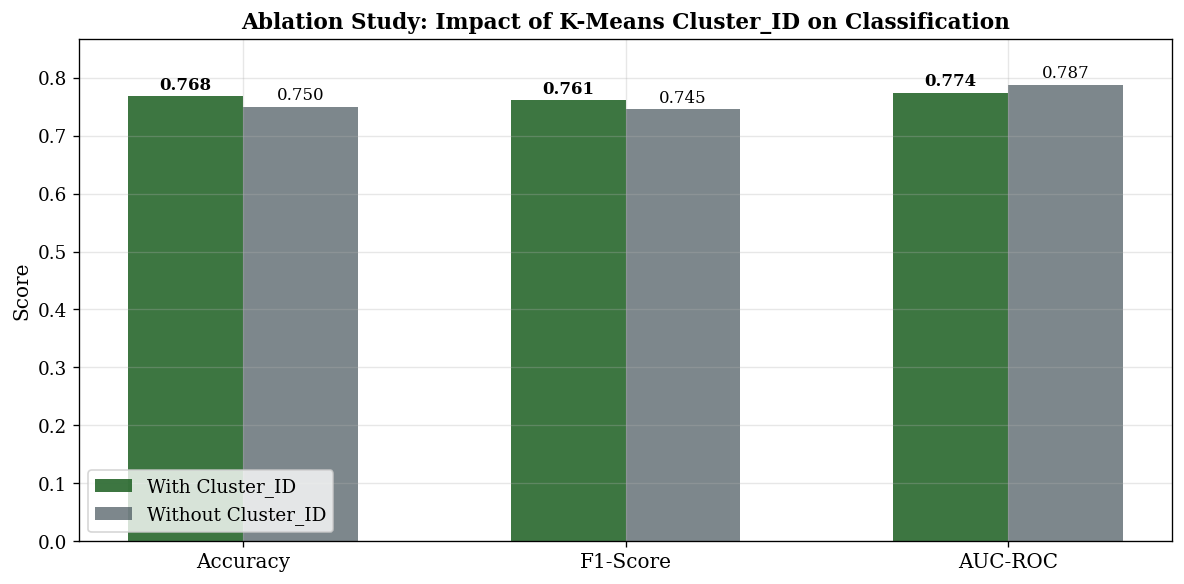

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1-Score', 'AUC-ROC']
with_vals = [accuracy, f1_score, auc_roc]
without_vals = [acc_nc, f1_nc, auc_nc]

x = np.arange(len(metrics))
width = 0.3

bars1 = ax.bar(x - width/2, with_vals, width, label='With Cluster_ID', color=PALETTE_BNP, alpha=0.85)
bars2 = ax.bar(x + width/2, without_vals, width, label='Without Cluster_ID', color=PALETTE_NEUTRAL, alpha=0.65)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score")
ax.set_title("Ablation Study: Impact of K-Means Cluster_ID on Classification", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(with_vals), max(without_vals)) + 0.08)
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()


## Executive Summary

This section consolidates all findings from the four analytical phases into a final report suitable for academic submission.


In [25]:
print("=" * 80)
print("EXECUTIVE SUMMARY")
print("13th Bangladesh National Parliamentary Election (February 12, 2026)")
print("=" * 80)

print(f"""
  PHASE 1: CORRELATION ANALYSIS
  - Method: Pearson + Spearman dual correlation matrices
  - Visualization: correlation_heatmap.png

  PHASE 2: REGRESSION ANALYSIS
  - Model A (Voter Turnout):    LR ElasticNet  | R2 = {r2_a:.4f} | RMSE = {rmse_a:.2f}%
  - Model B (Vote Share):       RF Regressor   | R2 = {r2_b:.4f} | RMSE = {rmse_b:.2f}%
  - Visualization: phase2_regression_plots.png

  PHASE 3: CLASSIFICATION (Capstone)
  - Target: BNP_COALITION vs JAMAAT_REFORM (binary)
  - Accuracy:    {accuracy:.4f}
  - F1-Score:    {f1_score:.4f}
  - AUC-ROC:     {auc_roc:.4f}
  - Baseline:    {majority_baseline:.4f}
  - Top Feature: {fi_pdf.iloc[0]['Feature']} ({fi_pdf.iloc[0]['Importance']:.4f})
  - Visualization: phase3_feature_importances.png, phase3_confusion_matrix.png

  PHASE 4: K-MEANS CLUSTERING
  - Optimal K = {optimal_k} (Silhouette = {silhouette_scores[optimal_k]:.4f})
  - Ablation: With Cluster = {accuracy:.4f} vs Without = {acc_nc:.4f}
  - Visualization: silhouette_analysis.png, ablation_study.png

  THESIS CONCLUSION
  The top socio-economic determinant of coalition victory was:
    1. {fi_pdf.iloc[0]['Feature']:<30s} ({fi_pdf.iloc[0]['Importance']:.4f})
    2. {fi_pdf.iloc[1]['Feature']:<30s} ({fi_pdf.iloc[1]['Importance']:.4f})
    3. {fi_pdf.iloc[2]['Feature']:<30s} ({fi_pdf.iloc[2]['Importance']:.4f})
""")

print("Pipeline execution complete. All four phases finalized.")
print("=" * 80)

spark.stop()


EXECUTIVE SUMMARY
13th Bangladesh National Parliamentary Election (February 12, 2026)

  PHASE 1: CORRELATION ANALYSIS
  - Method: Pearson + Spearman dual correlation matrices
  - Visualization: correlation_heatmap.png

  PHASE 2: REGRESSION ANALYSIS
  - Model A (Voter Turnout):    LR ElasticNet  | R2 = 0.6302 | RMSE = 5.23%
  - Model B (Vote Share):       RF Regressor   | R2 = -0.0051 | RMSE = 9.54%
  - Visualization: phase2_regression_plots.png

  PHASE 3: CLASSIFICATION (Capstone)
  - Target: BNP_COALITION vs JAMAAT_REFORM (binary)
  - Accuracy:    0.7679
  - F1-Score:    0.7609
  - AUC-ROC:     0.7738
  - Baseline:    0.7262
  - Top Feature: Youth_Electorate_Pct (0.1259)
  - Visualization: phase3_feature_importances.png, phase3_confusion_matrix.png

  PHASE 4: K-MEANS CLUSTERING
  - Optimal K = 2 (Silhouette = 0.7078)
  - Ablation: With Cluster = 0.7679 vs Without = 0.7500
  - Visualization: silhouette_analysis.png, ablation_study.png

  THESIS CONCLUSION
  The top socio-economic d